# Generative Models: VAEs, GANs, and Diffusion

## Generative vs Discriminative Models

All models we've built so far are **discriminative**: given an input x, predict label y. The model learns P(y|x).

A **generative model** is fundamentally different. It learns the entire distribution P(x) — the distribution of the data itself. Once you have P(x), you can sample new data points from it (generate images, text, audio that look/sound real).

Why is this harder? A discriminative model just needs to draw a decision boundary. A generative model needs to understand *the full structure of the data* — every pixel of every image.

```
Discriminative: P(y|x) — "Is this image a cat?" → cat=0.9
Generative:     P(x)   — "Generate a realistic image of a cat"
Conditional:    P(x|y) — "Generate an image conditioned on the label 'cat'"
```

---

## Part 1: Autoencoders — Learning Compressed Representations

An Autoencoder compresses the input into a small **latent code** z, then tries to reconstruct the original input from z. The bottleneck forces the encoder to keep only the most important information.

```
Input x → [Encoder] → z (bottleneck) → [Decoder] → x̂ ≈ x
           (784 → 32)                   (32 → 784)
```

The training objective is simply to minimize reconstruction error:
```
Loss = ||x - x̂||²   (MSE between input and output)
```

100.0%
100.0%
100.0%
100.0%


Epoch 1: Avg Loss = 0.0648
Epoch 2: Avg Loss = 0.0520
Epoch 3: Avg Loss = 0.0495
Epoch 4: Avg Loss = 0.0481
Epoch 5: Avg Loss = 0.0472
Epoch 6: Avg Loss = 0.0465
Epoch 7: Avg Loss = 0.0460
Epoch 8: Avg Loss = 0.0455
Epoch 9: Avg Loss = 0.0451
Epoch 10: Avg Loss = 0.0447


Text(0.0, 1.0, 'Reconstructed')

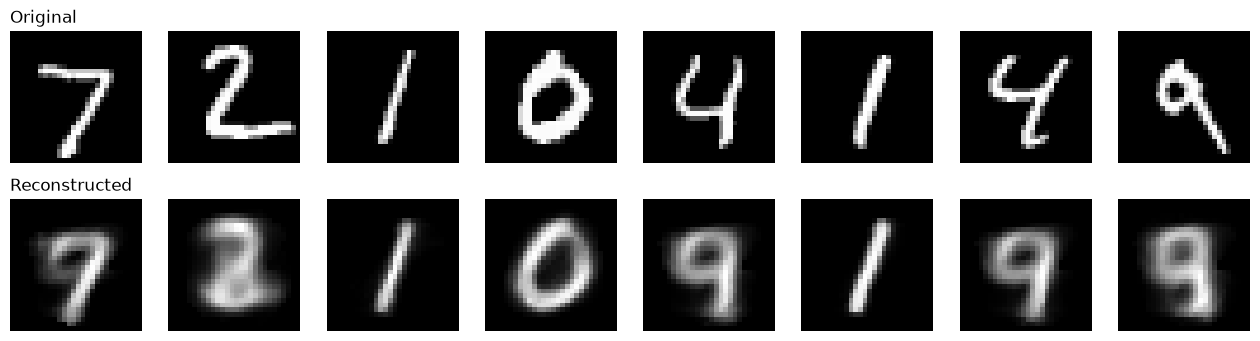

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- Data: MNIST (28×28 grayscale = 784 pixels per image) ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten (1,28,28) → (784,)
])

train_data = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=256, shuffle=False)


class Autoencoder(nn.Module):
    """
    Standard Autoencoder for MNIST.
    
    Encoder: 784 → 256 → latent_dim
    Decoder: latent_dim → 256 → 784
    
    The bottleneck forces the model to keep only the most important features.
    latent_dim=2 lets us visualize the latent space as a 2D scatter plot!
    """
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)   # No activation — raw latent code
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()                 # Output is in [0,1] to match normalized pixel values
        )
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        z    = self.encode(x)
        x_hat = self.decode(z)
        return x_hat


# --- Training the Autoencoder ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = Autoencoder(latent_dim=2).to(device)  # latent_dim=2 for visualization!

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    model.train()
    total_loss = 0
    for x, _ in train_loader:         # We don't need labels — unsupervised!
        x = x.to(device)
        
        x_hat = model(x)
        loss  = F.mse_loss(x_hat, x)  # Reconstruction loss: how different is x̂ from x?
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}: Avg Loss = {total_loss/len(train_loader):.4f}")


# --- Visualize: Original vs Reconstructed ---
model.eval()
with torch.no_grad():
    sample_x, _ = next(iter(test_loader))
    sample_x    = sample_x[:8].to(device)
    recon       = model(sample_x).cpu()
    sample_x    = sample_x.cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(sample_x[i].view(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].view(28, 28), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('Original', loc='left', fontsize=12)
axes[1, 0].set_title('Reconstructed', loc='left', fontsize=12)
# plt.show()

---

## Part 2: Variational Autoencoders (VAEs)

The standard autoencoder has a critical problem: its latent space is **discontinuous and irregular**. Points between two learned codes produce garbage when decoded, so you can't generate new samples by sampling from the latent space.

The VAE fixes this by forcing the latent space to be smooth and continuous. Instead of encoding to a single point z, it encodes to a **probability distribution**: a mean `μ` and a log-variance `log(σ²)`. A sample z is drawn from `N(μ, σ²)`.

```
Encoder: x → [μ, log(σ²)]    (two output vectors instead of one)
Sample:  z = μ + σ * ε       (ε ~ N(0,1) — the reparameterization trick)
Decoder: z → x̂
```

**Why ε ~ N(0,1) instead of sampling directly?**
We can't backpropagate through a random sampling operation. The reparameterization trick transforms the randomness into a separate input ε that doesn't require gradients. The gradient flows through μ and σ, but not through ε.

**The VAE Loss:** Reconstruction + KL Divergence
```
Loss = ||x - x̂||² + KL( N(μ,σ²) || N(0,1) )
         ↑                    ↑
    How well do we     How far is our latent distribution
    reconstruct x?     from the standard normal?
```

The KL term acts as a regularizer: it forces all encodings to stay near the origin with unit variance. This is what makes the latent space smooth.

Epoch 1: Loss = 209.85
Epoch 2: Loss = 177.68
Epoch 3: Loss = 170.82
Epoch 4: Loss = 167.58
Epoch 5: Loss = 165.46
Epoch 6: Loss = 163.97
Epoch 7: Loss = 162.75
Epoch 8: Loss = 161.69
Epoch 9: Loss = 160.72
Epoch 10: Loss = 159.88
Epoch 11: Loss = 159.17
Epoch 12: Loss = 158.53
Epoch 13: Loss = 157.91
Epoch 14: Loss = 157.40
Epoch 15: Loss = 156.89
Epoch 16: Loss = 156.44
Epoch 17: Loss = 156.02
Epoch 18: Loss = 155.66
Epoch 19: Loss = 155.26
Epoch 20: Loss = 154.87


Text(0.5, 0.98, 'Latent Space Interpolation: Digit A → Digit B')

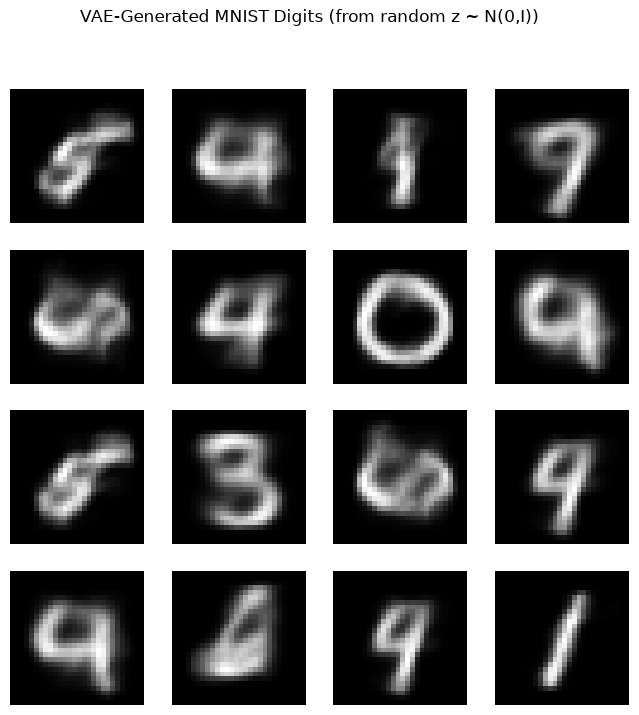

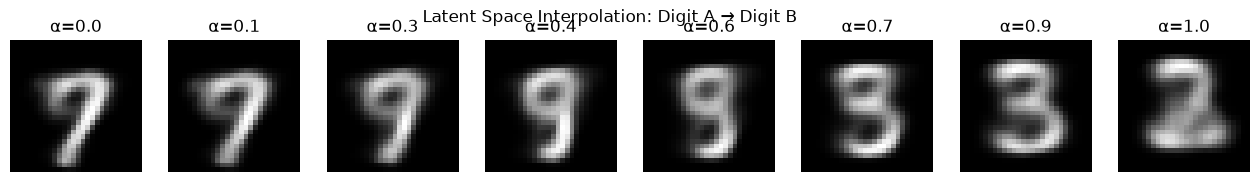

In [2]:
class VAE(nn.Module):
    """
    Variational Autoencoder.
    Key difference from plain Autoencoder: encoder outputs μ AND log(σ²),
    and we SAMPLE z from N(μ, σ²) using the reparameterization trick.
    """
    def __init__(self, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim
        
        # Shared encoder backbone
        self.encoder_base = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU()
        )
        # Two separate heads: one for mean, one for log-variance
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        
        # Decoder is the same as before
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )
    
    def encode(self, x):
        h      = self.encoder_base(x)
        mu     = self.fc_mu(h)      # Mean of the latent distribution
        logvar = self.fc_logvar(h)  # Log-variance (we learn log σ² for numerical stability)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """
        Sample z from N(mu, sigma^2) in a differentiable way.
        
        z = mu + sigma * epsilon
        where epsilon ~ N(0, 1)
        
        The gradient flows through mu and sigma (= exp(0.5 * logvar)).
        It does NOT flow through epsilon (that's just random noise, no parameters).
        """
        std     = torch.exp(0.5 * logvar)  # σ = exp(log(σ²)/2)
        epsilon = torch.randn_like(std)     # ε ~ N(0, I), same shape as std
        z       = mu + std * epsilon
        return z
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        x_hat      = self.decode(z)
        return x_hat, mu, logvar


def vae_loss(x_hat, x, mu, logvar):
    """
    VAE loss = Reconstruction loss + KL Divergence
    
    KL divergence between N(mu, sigma^2) and N(0, 1):
      KL = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
         = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    
    This is an analytical formula — no sampling needed for the KL term!
    """
    # Reconstruction: BCE works better than MSE for pixel values in [0,1]
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction='sum')
    
    # KL divergence (closed form for Gaussian vs N(0,1))
    # Negative because we want to MINIMIZE KL
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kl_loss


# Train the VAE
vae       = VAE(latent_dim=2).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(20):
    vae.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        
        x_hat, mu, logvar = vae(x)
        loss = vae_loss(x_hat, x, mu, logvar)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}: Loss = {total_loss/len(train_loader.dataset):.2f}")


# --- Generate new samples by sampling from the prior N(0, I) ---
vae.eval()
with torch.no_grad():
    # Sample 16 random latent vectors from standard normal
    z_samples = torch.randn(16, 2).to(device)  # Sample from N(0,I)
    generated = vae.decode(z_samples).cpu()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].view(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle('VAE-Generated MNIST Digits (from random z ~ N(0,I))')
# plt.show()


# --- Latent Space Interpolation: morph between two digits ---
with torch.no_grad():
    # Get latent codes for two specific test images
    x1, _ = test_data[0]
    x2, _ = test_data[1]
    x1 = x1.unsqueeze(0).to(device)
    x2 = x2.unsqueeze(0).to(device)
    
    mu1, _ = vae.encode(x1)
    mu2, _ = vae.encode(x2)
    
    # Interpolate 8 steps between the two latent codes
    interpolated = []
    for alpha in torch.linspace(0, 1, 8):
        z_interp = (1 - alpha) * mu1 + alpha * mu2  # Convex combination
        decoded  = vae.decode(z_interp)
        interpolated.append(decoded.squeeze().cpu())

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, (img, ax) in enumerate(zip(interpolated, axes)):
    ax.imshow(img.view(28, 28), cmap='gray')
    ax.set_title(f'α={i/7:.1f}')
    ax.axis('off')
plt.suptitle('Latent Space Interpolation: Digit A → Digit B')
# plt.show()

---
## References
*   [Kingma & Welling (2013): Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114) — The VAE paper
*   [Lilian Weng: From Autoencoder to Beta-VAE](https://lilianweng.github.io/posts/2018-08-12-vae/)